In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


import sys
import os

sys.path.append('..')
os.chdir('..')  

from src.utils.config_loader import load_config

config = load_config("configs/data_config.yaml")
print("Config loaded successfully ✅")

https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Electronics.jsonl.gz
Config loaded successfully ✅


In [2]:
# Load ratings data
raw_path = config['paths']['raw_data']

df_ratings = pd.read_parquet(raw_path + "Electronics_ratings.parquet")

print(f"Shape: {df_ratings.shape}")
print(f"\nColumns: {df_ratings.columns.tolist()}")
print(f"\nFirst 5 rows:")
df_ratings.head()

Shape: (1000000, 10)

Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

First 5 rows:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True


In [3]:
# Basic info about the data
print("=== Data Types ===")
print(df_ratings.dtypes)

print("\n=== Missing Values ===")
print(df_ratings.isnull().sum())

print("\n=== Rating Distribution ===")
print(df_ratings['rating'].value_counts().sort_index())

=== Data Types ===
rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object

=== Missing Values ===
rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

=== Rating Distribution ===
rating
1.0     89031
2.0     47705
3.0     71612
4.0    141739
5.0    649913
Name: count, dtype: int64


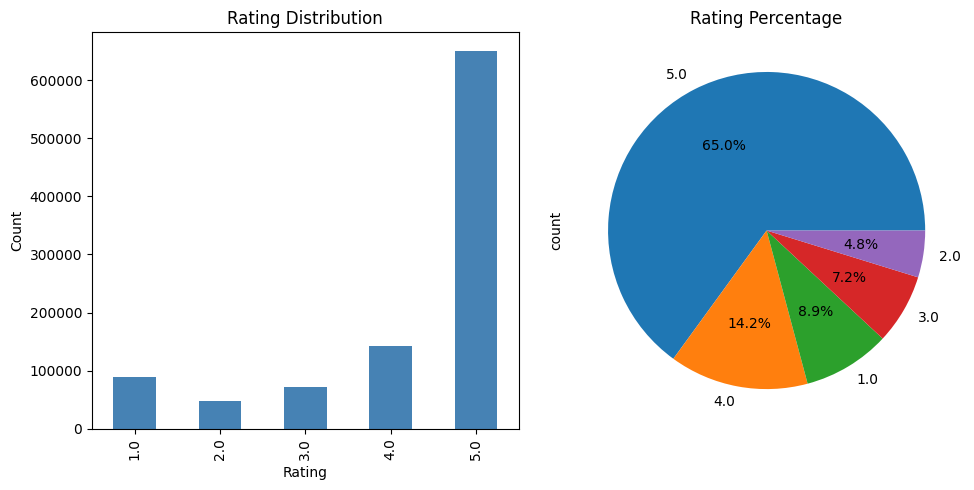

In [4]:
# Rating Distribution Plot
plt.figure(figsize=(10, 5))

# Plot 1 - Count
plt.subplot(1, 2, 1)
df_ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

# Plot 2 - Percentage
plt.subplot(1, 2, 2)
df_ratings['rating'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Rating Percentage')

plt.tight_layout()
plt.show()

In [5]:
# User Activity Analysis
print("=== Users Stats ===")
user_activity = df_ratings['user_id'].value_counts()

print(f"Total unique users:    {df_ratings['user_id'].nunique()}")
print(f"Total unique items:    {df_ratings['asin'].nunique()}")
print(f"Max reviews per user:  {user_activity.max()}")
print(f"Min reviews per user:  {user_activity.min()}")
print(f"Avg reviews per user:  {user_activity.mean():.2f}")


=== Users Stats ===
Total unique users:    185242
Total unique items:    317522
Max reviews per user:  1034
Min reviews per user:  1
Avg reviews per user:  5.40


In [6]:
print("=== Activity Distribution ===")
print(user_activity.value_counts().head(10))

=== Activity Distribution ===
count
1     58315
2     33834
3     21094
4     14767
5     10463
6      7750
7      6031
8      4808
9      3739
10     3100
Name: count, dtype: int64


Text(0, 0.5, 'Number of Users')

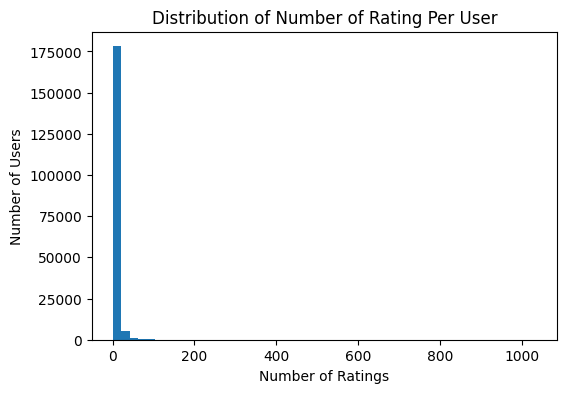

In [7]:
plt.figure(figsize=(6, 4))
plt.hist(user_activity, bins=50)
plt.title("Distribution of Number of Rating Per User")
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')


In [8]:
df_ratings['timestamp'] = pd.to_datetime(df_ratings['timestamp'], unit='ms', errors='coerce')
df_ratings['timestamp'].head()

0   2022-07-18 22:58:37.948
1   2020-06-20 18:42:29.731
2   2018-04-07 09:23:37.534
3   2010-11-20 18:41:35.000
4   2023-02-17 02:39:41.238
Name: timestamp, dtype: datetime64[ns]

In [9]:
df_ratings.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-07-18 22:58:37.948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-06-20 18:42:29.731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:23:37.534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,2010-11-20 18:41:35.000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,2023-02-17 02:39:41.238,0,True


In [10]:
df_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   rating             1000000 non-null  float64       
 1   title              1000000 non-null  object        
 2   text               1000000 non-null  object        
 3   images             1000000 non-null  object        
 4   asin               1000000 non-null  object        
 5   parent_asin        1000000 non-null  object        
 6   user_id            1000000 non-null  object        
 7   timestamp          1000000 non-null  datetime64[ns]
 8   helpful_vote       1000000 non-null  int64         
 9   verified_purchase  1000000 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 69.6+ MB


In [11]:
df_ratings.describe()

,rating,timestamp,helpful_vote
count,1000000.000000,1000000,1000000.000000
mean,4.215798,2018-03-22 06:53:56.743938816,1.418708
min,1.000000,1998-03-03 12:17:02,0.000000
25%,4.000000,2016-01-05 03:45:06.750000128,0.000000
50%,5.000000,2018-07-03 20:05:29.106500096,0.000000
75%,5.000000,2020-10-16 23:31:11.549499904,0.000000
max,5.000000,2023-03-20 20:48:25.319000,8722.000000
std,1.291146,NaN,25.691746


Text(0, 0.5, 'HelpFul Votes')

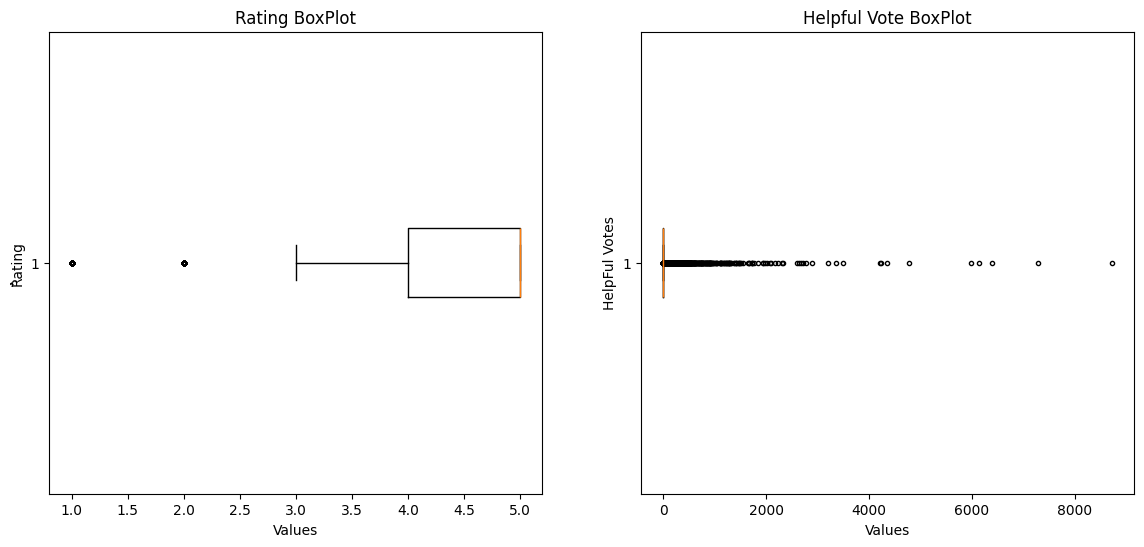

In [12]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.boxplot(df_ratings['rating'], vert=False, flierprops=dict(marker='o', markersize=3))
plt.title('Rating BoxPlot')
plt.xlabel('Values')
plt.ylabel('ٌRating')

plt.subplot(1, 2, 2)
plt.boxplot(df_ratings['helpful_vote'], vert=False, flierprops=dict(marker='o', markersize=3))
plt.title('Helpful Vote BoxPlot')
plt.xlabel('Values')
plt.ylabel('HelpFul Votes')

In [13]:
Q1 = df_ratings['helpful_vote'].quantile(0.25)
Q3 = df_ratings['helpful_vote'].quantile(0.75)
IQR = Q3 - Q1

outliers = df_ratings[df_ratings['helpful_vote'] > Q3 + IQR * 1.5]
print(f"Outliers count: {len(outliers)}")
print(f"Outliers %: {len(outliers)/len(df_ratings)*100:.2f}%")

Outliers count: 234083
Outliers %: 23.41%


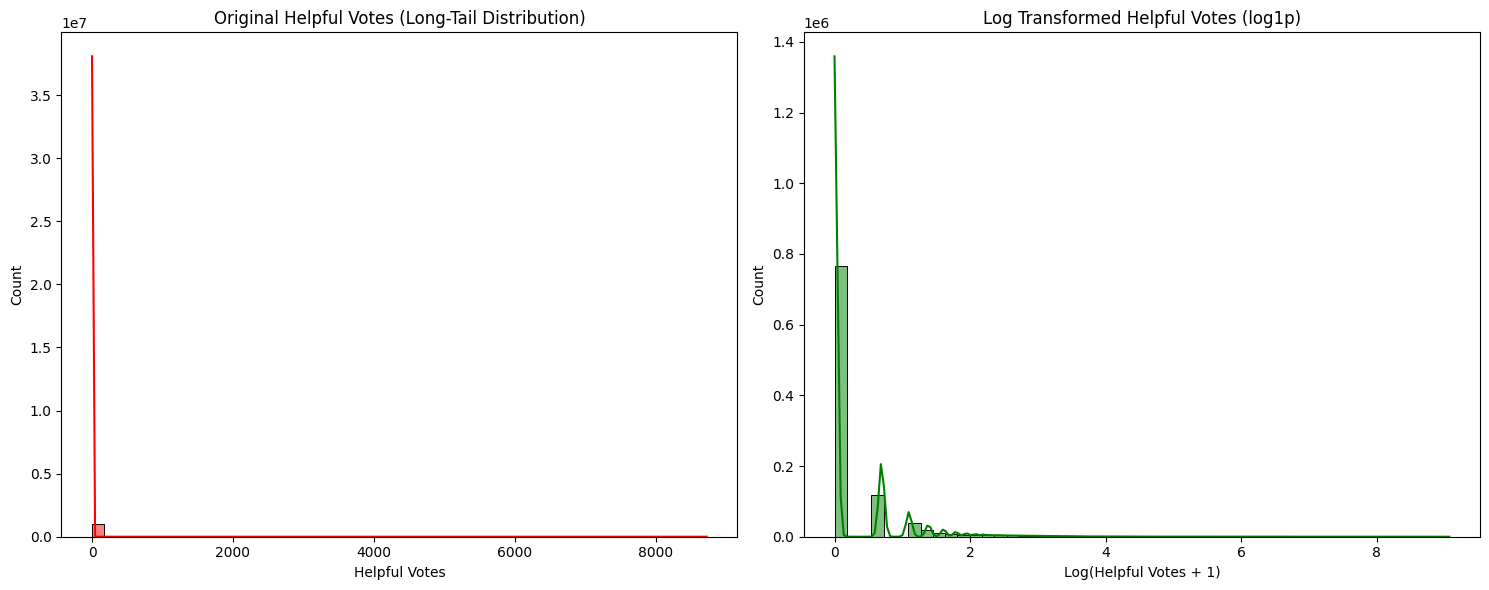

In [14]:
df_ratings['helpful_vote_log'] = np.log1p(df_ratings['helpful_vote'])

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_ratings['helpful_vote'], bins=50, kde=True, color='red')
plt.title('Original Helpful Votes (Long-Tail Distribution)')
plt.xlabel('Helpful Votes')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(df_ratings['helpful_vote_log'], bins=50, kde=True, color='green')
plt.title('Log Transformed Helpful Votes (log1p)')
plt.xlabel('Log(Helpful Votes + 1)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [15]:
df_ratings = df_ratings.replace(
    [r"^\s*$", "null", "NULL", "None", "none",
     "NaN", "nan", "N/A", "n/a"],
    pd.NA,
    regex=True
)

In [16]:
df_ratings[df_ratings['title'].isnull()]


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,helpful_vote_log
2083,5.0,<NA>,Work fine perfect,[],B00PIWB2SO,B0BKLWZ4LD,AHB5CGLYN3Y6NIPHNQLYFJT2W2PQ,2018-10-19 22:41:37.080,0,True,0.000000
5857,5.0,<NA>,My grandson loves how he can hear his shows be...,[],B00MO86ES8,B00MO86ES8,AF6COLVCUDL5WZZMOBHMCNCBQMEA,2020-06-23 00:34:48.272,0,True,0.000000
7083,1.0,<NA>,<NA>,"[{'attachment_type': 'IMAGE', 'large_image_url...",B07ZZKC52P,B07ZZKC52P,AGUO64P7C4QQ3NVBLJAHCGLLUCQA,2020-02-13 14:06:53.192,1,True,0.693147
8049,1.0,<NA>,<NA>,[],B07GW9TJ3G,B07GW9TJ3G,AFVWRJSFTXSLWZUPRKKTVPY5JQRA,2022-04-24 14:40:18.350,0,True,0.000000
8994,5.0,<NA>,Great production,[],B0825TN7N8,B0859VXQF9,AE36THZQWROP2Z74SSA774SF36QQ,2021-05-04 20:45:52.632,0,True,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
995070,3.0,<NA>,"well constructed, only one CON too lose in som...",[],B006U3O566,B0BKR9NMMF,AEZVOTEGODENHUAQOG7AUETY6YGQ,2015-01-02 18:48:55.000,0,True,0.000000
997225,3.0,<NA>,"The functionality of this mouse is excellent, ...",[],B002HWRJBM,B002HWRJBM,AEPFH6UA3LJQOKFV25RIZKL43EFA,2010-07-23 11:03:18.000,0,True,0.000000
998224,3.0,<NA>,<NA>,[],B003CFATNS,B00JEANVMG,AGTPJE6OXN7IURUKNZKAE4B2TLZQ,2014-09-14 23:18:30.000,2,True,1.098612
999215,5.0,<NA>,Nice product for the price. I have used them f...,[],B006U3O566,B0BKR9NMMF,AEUIJXB2ID73XMTFVF5QVMK4GOSQ,2015-02-27 22:37:41.000,0,True,0.000000


In [17]:
df_ratings.dropna(subset=['title', 'text'], inplace=True)

In [18]:
df_ratings[df_ratings['title'].isnull()]
df_ratings[df_ratings['text'].isnull()]

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,helpful_vote_log


In [19]:
df_ratings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 990761 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             990761 non-null  float64       
 1   title              990761 non-null  object        
 2   text               990761 non-null  object        
 3   images             990761 non-null  object        
 4   asin               990761 non-null  object        
 5   parent_asin        990761 non-null  object        
 6   user_id            990740 non-null  object        
 7   timestamp          990761 non-null  datetime64[ns]
 8   helpful_vote       990761 non-null  int64         
 9   verified_purchase  990761 non-null  bool          
 10  helpful_vote_log   990761 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 84.1+ MB


In [20]:
df_ratings = df_ratings.dropna(subset=['user_id'])

In [21]:
df_ratings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 990740 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             990740 non-null  float64       
 1   title              990740 non-null  object        
 2   text               990740 non-null  object        
 3   images             990740 non-null  object        
 4   asin               990740 non-null  object        
 5   parent_asin        990740 non-null  object        
 6   user_id            990740 non-null  object        
 7   timestamp          990740 non-null  datetime64[ns]
 8   helpful_vote       990740 non-null  int64         
 9   verified_purchase  990740 non-null  bool          
 10  helpful_vote_log   990740 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 84.1+ MB


In [22]:
df_ratings = df_ratings.drop(columns=['images'])


In [23]:
df_ratings.duplicated().value_counts()

False    988268
True       2472
Name: count, dtype: int64

In [24]:
df_ratings.duplicated().sum()

np.int64(2472)

In [25]:
df_ratings.duplicated(subset=['user_id', 'asin']).sum()

np.int64(2476)

In [26]:
df_ratings.drop_duplicates(inplace=True)

In [27]:
df_ratings.duplicated().sum()

np.int64(0)

In [28]:
df_ratings.duplicated(subset=['user_id', 'asin']).sum()

np.int64(4)

In [29]:
df_ratings = df_ratings.drop_duplicates(subset=['user_id', 'asin'])

In [30]:
df_ratings.duplicated(subset=['user_id', 'asin']).sum()

np.int64(0)

In [31]:
print(len(df_ratings))

988264


=== Number of Ratings Per Year ===
timestamp
1998         1
1999         4
2000        41
2001        99
2002       163
2003       225
2004       350
2005       573
2006       982
2007      2217
2008      2859
2009      3924
2010      6658
2011     11736
2012     19595
2013     40668
2014     64525
2015     90357
2016    103754
2017     94380
2018     94259
2019    113831
2020    113172
2021    107693
2022     94546
2023     21652
Name: count, dtype: int64
------------------------------


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_27268\4020741551.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_counts.index.astype(int), y=yearly_counts.values, palette='viridis')


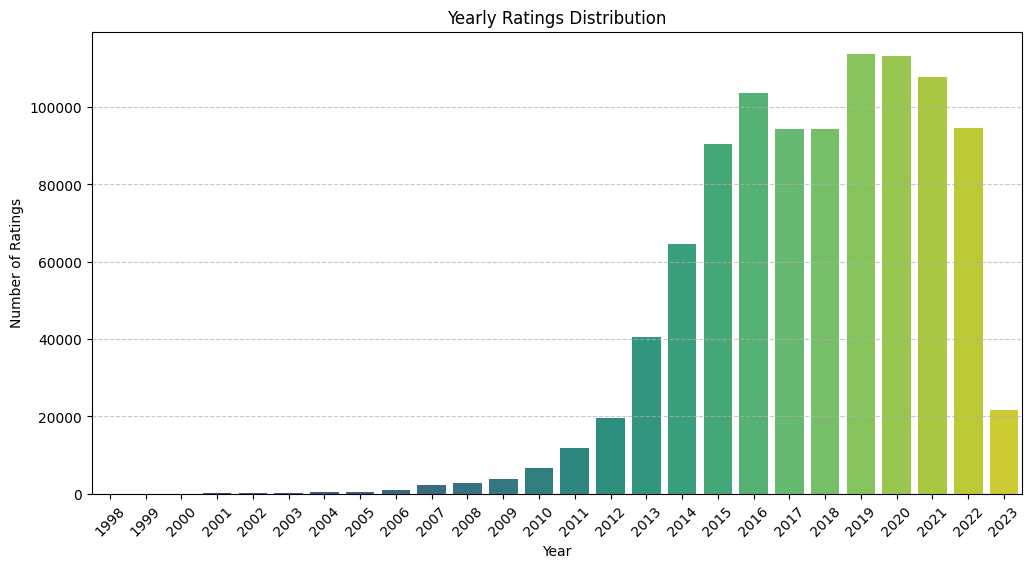

In [ ]:
# Calculate the number of ratings per year and sort chronologically
yearly_counts = df_ratings['timestamp'].dt.year.value_counts().sort_index()

# Print the distribution table
print("=== Number of Ratings Per Year ===")
print(yearly_counts)
print("-" * 30)

# Plot the yearly ratings distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=yearly_counts.index.astype(int), y=yearly_counts.values, palette='viridis')

plt.title('Yearly Ratings Distribution')
plt.xlabel('Year')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

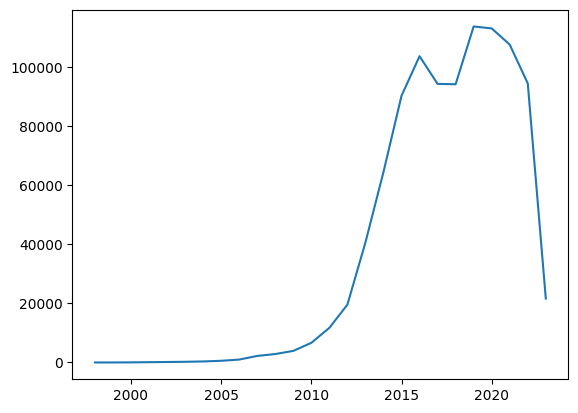

In [33]:
time_curve = df_ratings['timestamp'].dt.year.value_counts().sort_index()
plt.plot(time_curve.index, time_curve.values)

In [34]:
n_users = df_ratings['user_id'].nunique()
n_items = df_ratings['asin'].nunique()
n_ratings = len(df_ratings)

sparsity = (1 - n_ratings / (n_users * n_items)) * 100
print(f"Sparsity: {sparsity:.2f}%")
# # Sparsity = 100% - This is normal for recommendation systems
# Solution: Matrix Factorization handles sparse data efficiently

Sparsity: 100.00%


In [30]:
# # TODO: Use time-based train/test split
# Train: before 2022
# Test:  2022 onwards

In [31]:
# TODO: Spam Detection in Preprocessing
# 1. Remove users with > 5 reviews per day
# 2. Check inter-review time - if seconds apart = bot

In [35]:
# Item Activity Analysis
print("=== Item Stats ===")
item_activity = df_ratings['asin'].value_counts()

print(f"Total unique items:    {df_ratings['asin'].nunique()}")
print(f"Max reviews per item:  {item_activity.max()}")
print(f"Min reviews per item:  {item_activity.min()}")
print(f"Avg reviews per item:  {item_activity.mean():.2f}")


=== Item Stats ===
Total unique items:    315535
Max reviews per item:  5164
Min reviews per item:  1
Avg reviews per item:  3.13


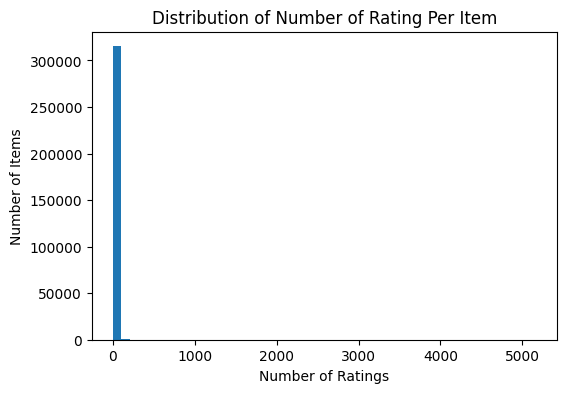

In [36]:
plt.figure(figsize=(6, 4))
plt.hist(item_activity, bins=50)
plt.title("Distribution of Number of Rating Per Item")
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Items')
plt.show()


In [ ]:
# TODO: Handle Item Cold Start in Preprocessing
# Items with < 5 reviews = consider removing or special handling

In [37]:
item_activity.head(10)

asin
B01G8JO5F2    5164
B00ZV9RDKK    3485
B079QHML21    2514
B00TYFCJ8S    2295
B01DFKC2SO    2213
B014YN7LVE    2203
B00R92CL5E    2089
B07V42JLFH    2020
B0047T79VS    1767
B00L0YLRUW    1595
Name: count, dtype: int64

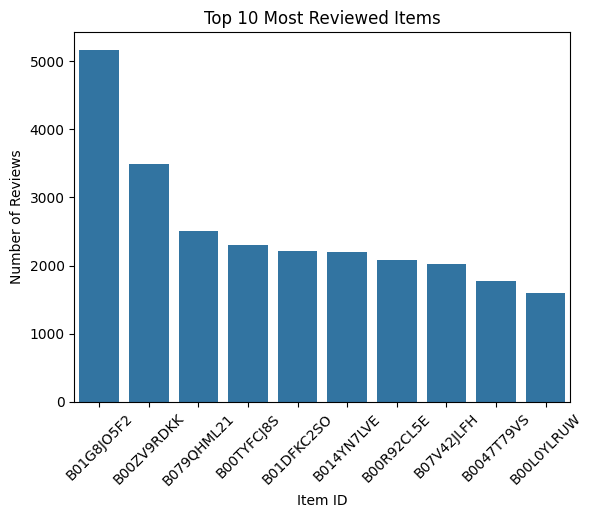

In [38]:
top_10 = item_activity.head(10)

sns.barplot(x=top_10.index, y=top_10.values)
plt.title('Top 10 Most Reviewed Items')
plt.xlabel('Item ID')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.show()

In [39]:
df_ratings['verified_purchase'] = df_ratings['verified_purchase'].astype(int)

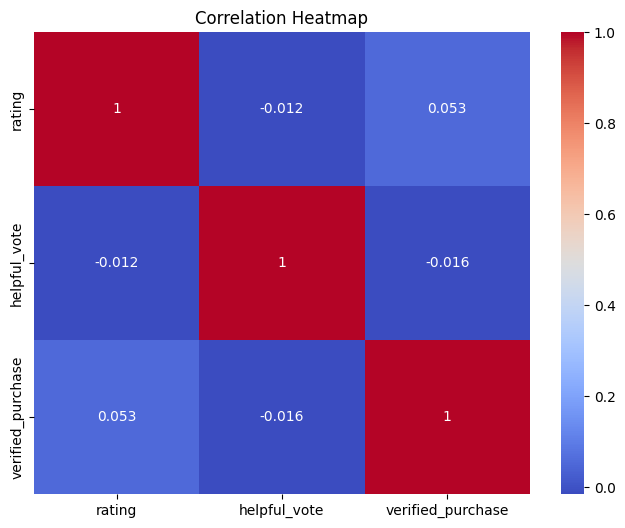

In [40]:
# Correlation Heatmap
correlation = df_ratings[["rating", "helpful_vote", "verified_purchase"]].corr()


plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [41]:
df_ratings.groupby('verified_purchase')['rating'].mean()

verified_purchase
0    4.009734
1    4.242088
Name: rating, dtype: float64

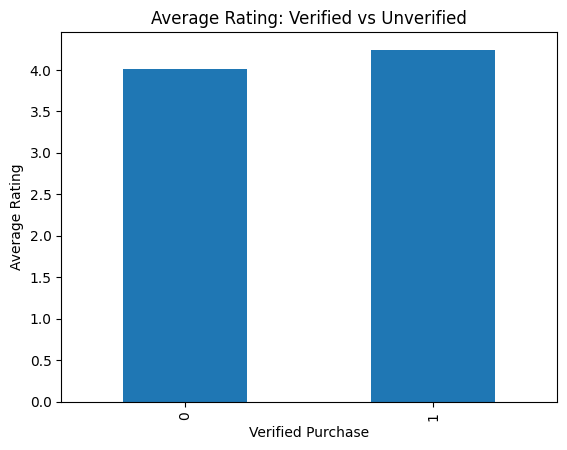

In [42]:
df_ratings.groupby('verified_purchase')['rating'].mean().plot(kind='bar')
plt.title('Average Rating: Verified vs Unverified')
plt.xlabel('Verified Purchase')
plt.ylabel('Average Rating')
plt.show()

In [ ]:
# TODO: In Preprocessing
# Add weight column:
# verified_purchase = 1 → weight = 1.0
# verified_purchase = 0 → weight = 0.7

In [48]:
print(df_ratings['text'].str.len().max())
print(df_ratings['text'].str.len().mean())
print(df_ratings['text'].str.len().min())

24070
288.5117377542843
1


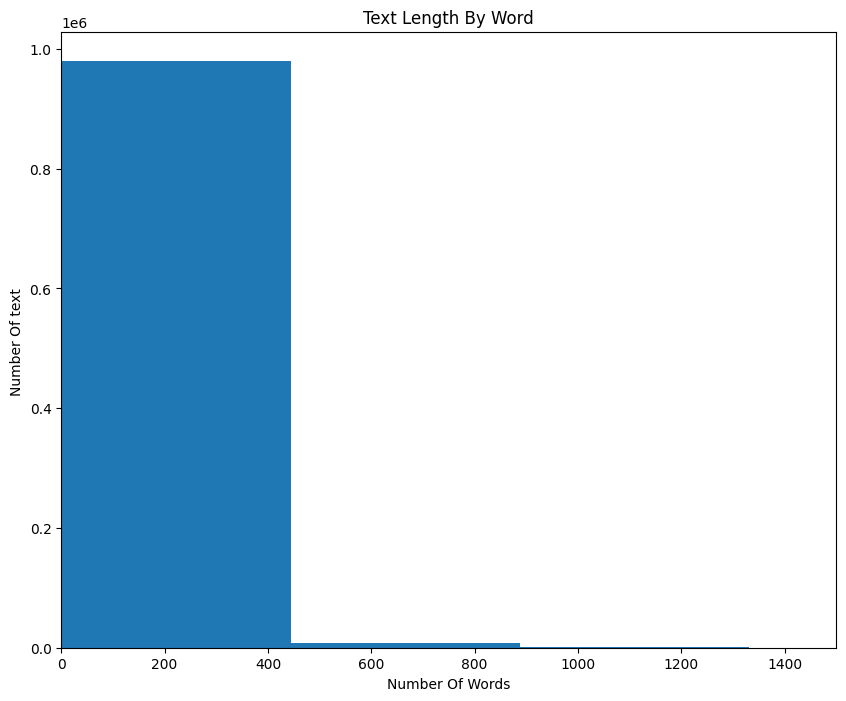

In [43]:
text_words = df_ratings['text'].str.split().str.len()
plt.figure(figsize=(10, 8))
plt.hist(text_words)
plt.title('Text Length By Word')
plt.xlabel('Number Of Words')
plt.ylabel('Number Of text ')
plt.xlim(0, 1500)

plt.show()

In [44]:
less_than_5 = (text_words < 5).sum()
print(f"Reviews Lower Than 5 Words {less_than_5}")
print(f"Percentage : {less_than_5/len(df_ratings)*100:.2f}%")

Reviews Lower Than 5 Words 122169
Percentage : 12.36%


In [ ]:
# TODO: In Preprocessing - Text Filtering
# If review < 5 words → use rating only, ignore text
# If review >= 5 words → use rating + text
# Truncate reviews > 250 words

In [45]:
user_counts = df_ratings.groupby('user_id')['rating'].count()

df_ratings['user_activity'] = df_ratings['user_id'].map(user_counts)

df_ratings['user_segment'] = pd.cut(df_ratings['user_activity'],
                                    bins=[0, 2, 10, np.inf],
                                    labels=['Light', 'Medium', 'Heavy'])

print(df_ratings['user_segment'].value_counts())

user_segment
Heavy     497152
Medium    365050
Light     126062
Name: count, dtype: int64


<Axes: ylabel='count'>

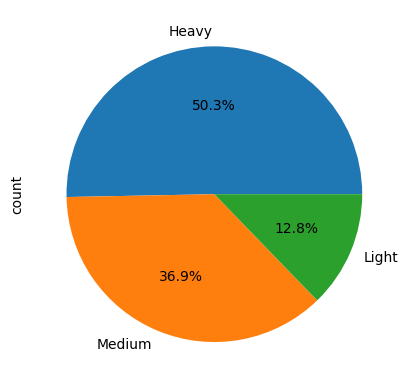

In [46]:
df_ratings['user_segment'].value_counts().plot( kind='pie', autopct='%1.1f%%')

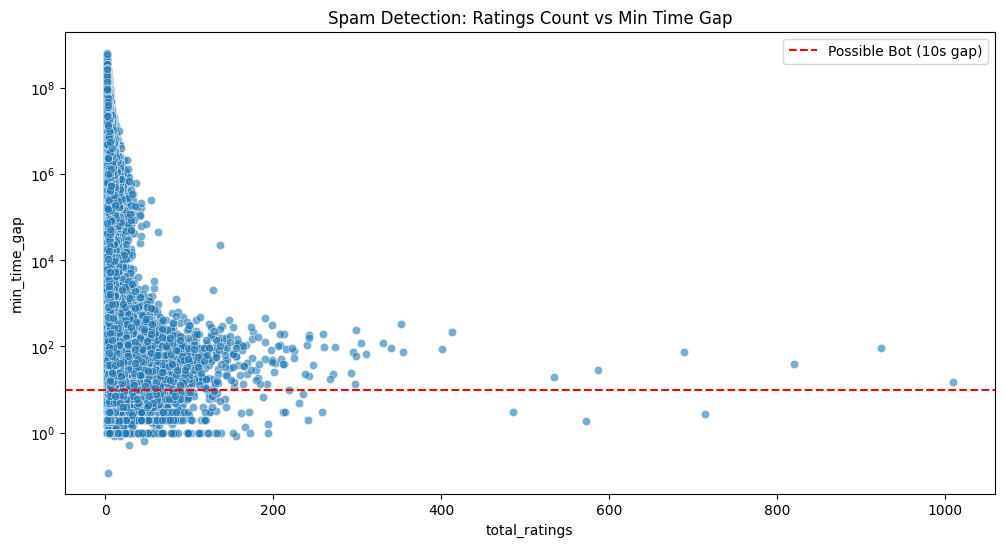

In [47]:
df = df_ratings.sort_values(['user_id', 'timestamp'])

df['time_diff'] = df.groupby('user_id')['timestamp'].diff().dt.total_seconds()

user_spam_check = df.groupby('user_id').agg({
    'rating': 'count',
    'time_diff': 'min'  
}).rename(columns={'rating': 'total_ratings', 'time_diff': 'min_time_gap'})

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.scatterplot(data=user_spam_check, x='total_ratings', y='min_time_gap', alpha=0.6)

plt.axhline(y=10, color='r', linestyle='--', label='Possible Bot (10s gap)')
plt.yscale('log')
plt.title('Spam Detection: Ratings Count vs Min Time Gap')
plt.legend()
plt.show()

In [ ]:
# TODO: Spam Detection in Preprocessing - Use Both Methods:
# Method 1: Remove users with > 5 reviews per day
# Method 2: Remove users with min_time_gap < 10 seconds between reviews
# Users flagged by either method = potential bot → remove

In [ ]:
# ============ FUTURE IMPROVEMENTS ============
# 1. ML-based spam detection model
# 2. Advanced feedback loop integration  
# 3. Cross-domain recommendations
# 4. A/B Testing framework
# =============================================